# SIOC 251: Homework 3 — Part III

**Sophie Wynn**

---
## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl



---
## Carryover from Parts I and II



In [ ]:
def sample_path_length(rng):
    """Draw a path length in optical-depth units from the exponential CDF."""
    zeta = rng.uniform(0.0, 1.0)
    return -np.log(1.0 - zeta)

def sample_scatter_angles_isotropic(rng):
    """Return (cos_Theta, Phi) for an isotropic scattering event."""
    cos_theta = 2.0 * rng.uniform(0.0, 1.0) - 1.0
    phi       = 2.0 * np.pi * rng.uniform(0.0, 1.0)
    return cos_theta, phi

def sample_scatter_angles_hg(g, rng):
    """Return (cos_Theta, Phi) for a Henyey-Greenstein scattering event."""
    zeta = rng.uniform(0.0, 1.0)
    if abs(g) < 1e-6:
        cos_theta = 2.0 * zeta - 1.0
    else:
        inner = (1.0 - g**2) / (1.0 - g + 2.0 * g * zeta)
        cos_theta = (1.0 + g**2 - inner**2) / (2.0 * g)
        cos_theta = float(np.clip(cos_theta, -1.0, 1.0))
    phi = rng.uniform(0.0, 2.0 * np.pi)
    return cos_theta, phi

def rotate_to_model_frame(k_in, cos_theta, phi):
    """Rotate a scattered direction back into model coordinates (appendix procedure)."""
    sin_theta = np.sqrt(max(0.0, 1.0 - cos_theta**2))
    kp = np.array([sin_theta * np.cos(phi),
                   sin_theta * np.sin(phi),
                   cos_theta])
    kx, ky, kz = k_in
    horiz = np.hypot(kx, ky)
    if horiz < 1e-12:
        xp = np.array([1.0, 0.0, 0.0])
    else:
        xp = np.array([-ky, kx, 0.0]) / horiz
    zp = k_in
    yp = np.cross(zp, xp)
    k_new = kp[0] * xp + kp[1] * yp + kp[2] * zp
    return k_new / np.linalg.norm(k_new)


Primitives loaded.


---
## Part III.1 — Model Construction


### Cloud optical depth from microphysics

Standard parameterization:
$$\tau_{\rm cloud} \;=\; \frac{3}{2}\,\frac{\text{LWP}}{\rho_w\,R_{\rm eff}}, \qquad \text{LWP} = \text{LWC} \times \Delta z.$$


In [3]:
#create a function to calculate the cloud optical depth 
def cloud_optical_depth(reff_um, lwc_g_m3, thickness_m):
    """Cloud optical depth from effective radius, liquid water content, and thickness."""
    # Constants
    rho_water = 1000  # kg/m^3
    # Convert units
    reff_m = reff_um * 1e-6  
    lwc_kg_m3 = lwc_g_m3 * 1e-3  # convert g/m^3 to kg/m^3
    LWP = lwc_kg_m3 * thickness_m  #water path in kg/m^2
    #calculate tau
    tau_cloud = (3 * LWP) / (2 * rho_water * reff_m)
    return tau_cloud

# example usage
reff_um = 11 #mean effective radius in microns
lwc_g_m3 = 0.30  # liquid water content in g/m^3
thickness_m = 250.0  # cloud thickness in meters
tau_cloud = cloud_optical_depth(reff_um, lwc_g_m3, thickness_m)
print(f"Cloud optical depth: {tau_cloud:.2f}")

Cloud optical depth: 10.23


### Clear-sky optical depth from pressure scaling

Assume $\tau_{\rm clear} \propto p$, so the optical depth of a layer between pressures $p_{\rm top}$ and $p_{\rm bot}$ is
$$\tau_{\rm layer} \;=\; \tau_{\rm total}^{\rm clear} \,\frac{p_{\rm bot} - p_{\rm top}}{p_{\rm surf}}.$$

Pick a reasonable total clear-sky $\tau^{\rm clear}_{\rm total}$ (e.g. 0.1 in the visible) and partition it between "above the cloud" and "below the cloud" using pressure-altitude relations.

In [4]:
P_SURF = 1013.25   # standard surface pressure, hPa
# make a 
def clear_sky_tau_layer(tau_total_clear, p_top, p_bot, p_surf=P_SURF):
    return tau_total_clear * (p_bot - p_top) / p_surf

def pressure_at_altitude(z_m, p_surf=P_SURF, H=8000.0):
    # p(z) = p_surf * exp(-z/H)."""

    return p_surf * np.exp(-z_m / H)

# 
z_cloud_top = 1000.0   # m
z_cloud_bot = 750.0    # m

# Convert to pressures
p_cloud_top = pressure_at_altitude(z_cloud_top)
p_cloud_bot = pressure_at_altitude(z_cloud_bot)

print(f"p_surf       = {P_SURF:.1f} hPa")
print(f"p_cloud_bot  = {p_cloud_bot:.1f} hPa   (z = {z_cloud_bot:.0f} m)")
print(f"p_cloud_top  = {p_cloud_top:.1f} hPa   (z = {z_cloud_top:.0f} m)")
print(f"p_TOA        = ~0 hPa\n")

# --- Layer optical depths ---
tau_total_clear = 0.10   

tau_above = clear_sky_tau_layer(tau_total_clear, p_top=0.0,         p_bot=p_cloud_top)
tau_below = clear_sky_tau_layer(tau_total_clear, p_top=p_cloud_bot, p_bot=P_SURF)

print(f"tau_above_cloud = {tau_above:.4f}   "
      f"(fraction of column: {(p_cloud_top - 0.0)/P_SURF*100:.1f}%)")
print(f"tau_below_cloud = {tau_below:.4f}   "
      f"(fraction of column: {(P_SURF - p_cloud_bot)/P_SURF*100:.1f}%)")
print(f"sum             = {tau_above + tau_below:.4f}")

p_surf       = 1013.2 hPa
p_cloud_bot  = 922.6 hPa   (z = 750 m)
p_cloud_top  = 894.2 hPa   (z = 1000 m)
p_TOA        = ~0 hPa

tau_above_cloud = 0.0882   (fraction of column: 88.2%)
tau_below_cloud = 0.0089   (fraction of column: 8.9%)
sum             = 0.0972


In [5]:
## make a function for making the three layers using  the function clear_sky_tau_layer and cloud_optical_depth,
## this function will return a list of three dicts, one for each layer, with the keys: name, tau_top, tau_bot, omega, g, z_top, z_bot, p_top, p_bot
## then the MC model will be able to use this function to create the layers list it needs for the simulation, 

def make_layers(
    # --- cloud geometry & microphysics ---
    z_cloud_top_m    = 1000.0,     # cloud top altitude (m)
    cloud_thickness_m = 250.0,     # cloud geometric thickness (m)
    reff_um          = 11.0,       # effective droplet radius (μm)
    lwc_g_m3         = 0.30,       # liquid water content (g/m^3)
    # --- cloud optical properties ---
    omega_cloud = 1.0,             # cloud single-scatter albedo (assignment: 1.0)
    g_cloud     = 0.8,             # cloud asymmetry parameter (assignment: 0.8)
    # --- clear-sky properties ---
    tau_total_clear = 0.10,        # total clear-sky tau, full column
    omega_sky       = 0.5,         # clear-sky single-scatter albedo
    g_sky           = 0.0,         # clear-sky g (isotropic per assignment)
    # --- atmosphere physics ---
    p_surf = 1013.25,              # surface pressure (hPa)
    H      = 8000.0,               # atmospheric scale height (m)
):
    """Build the three-layer (above cloud, cloud, below cloud) layers list
    that run_monte_carlo_cloud expects.

    Returns
    -------
    layers : list of dicts ordered top-down
        Each dict has: name, tau_top, tau_bot, omega, g,
                       plus altitudes (z_top, z_bot) and pressures (p_top, p_bot)
                       for inspection / plotting.
    """
    # --- Geometry ---
    z_cloud_bot_m = z_cloud_top_m - cloud_thickness_m

    # --- Altitudes for each layer ---
    z_above_top  = np.inf
    z_above_bot  = z_cloud_top_m
    z_cloud_top_ = z_cloud_top_m
    z_cloud_bot_ = z_cloud_bot_m
    z_below_top  = z_cloud_bot_m
    z_below_bot  = 0.0

    # --- Pressures (via barometric formula) ---
    def p_of_z(z):
        return p_surf * np.exp(-z / H)

    p_above_top, p_above_bot = 0.0, p_of_z(z_above_bot)        # 0 → cloud top
    p_cloud_top_, p_cloud_bot_ = p_of_z(z_cloud_top_), p_of_z(z_cloud_bot_)
    p_below_top, p_below_bot = p_of_z(z_below_top), p_surf      # cloud bot → surface

    # --- Optical depths ---
    tau_above = clear_sky_tau_layer(tau_total_clear,
                                    p_top=p_above_top, p_bot=p_above_bot,
                                    p_surf=p_surf)
    tau_below = clear_sky_tau_layer(tau_total_clear,
                                    p_top=p_below_top, p_bot=p_below_bot,
                                    p_surf=p_surf)
    tau_cloud = cloud_optical_depth(reff_um=reff_um,
                                    lwc_g_m3=lwc_g_m3,
                                    thickness_m=cloud_thickness_m)

    # --- Layers, top-down, with cumulative tau boundaries ---
    layers = [
        {
            'name':    'above cloud',
            'tau_top': 0.0,
            'tau_bot': tau_above,
            'omega':   omega_sky,
            'g':       g_sky,
            'z_top':   z_above_top, 'z_bot': z_above_bot,
            'p_top':   p_above_top, 'p_bot': p_above_bot,
        },
        {
            'name':    'cloud',
            'tau_top': tau_above,
            'tau_bot': tau_above + tau_cloud,
            'omega':   omega_cloud,
            'g':       g_cloud,
            'z_top':   z_cloud_top_, 'z_bot': z_cloud_bot_,
            'p_top':   p_cloud_top_, 'p_bot': p_cloud_bot_,
        },
        {
            'name':    'below cloud',
            'tau_top': tau_above + tau_cloud,
            'tau_bot': tau_above + tau_cloud + tau_below,
            'omega':   omega_sky,
            'g':       g_sky,
            'z_top':   z_below_top, 'z_bot': z_below_bot,
            'p_top':   p_below_top, 'p_bot': p_below_bot,
        },
    ]
    return layers


layers = make_layers()
for L in layers:
    tau_layer = L['tau_bot'] - L['tau_top']
    print(f"{L['name']:>12}:  Δτ = {tau_layer:.5f}    "
          f"cum τ ∈ [{L['tau_top']:.4f}, {L['tau_bot']:.4f}]    "
          f"ω = {L['omega']:.2f}, g = {L['g']:.2f}    "
          f"z ∈ [{L['z_bot']:.0f}, {L['z_top']:.0f}] m    "
          f"p ∈ [{L['p_top']:.1f}, {L['p_bot']:.1f}] hPa")   


 above cloud:  Δτ = 0.08825    cum τ ∈ [0.0000, 0.0882]    ω = 0.50, g = 0.00    z ∈ [1000, inf] m    p ∈ [0.0, 894.2] hPa
       cloud:  Δτ = 10.22727    cum τ ∈ [0.0882, 10.3155]    ω = 1.00, g = 0.80    z ∈ [750, 1000] m    p ∈ [894.2, 922.6] hPa
 below cloud:  Δτ = 0.00895    cum τ ∈ [10.3155, 10.3245]    ω = 0.50, g = 0.00    z ∈ [0, 750] m    p ∈ [922.6, 1013.2] hPa


In [9]:
def run_monte_carlo_cloud(layers, sza_deg, n_photons=30_000, rng=np.random.default_rng(seed=1),
                          n_traces=0):
    """Three-layer (or N-layer) Monte Carlo for HW3 Part III.
    
    Parameters
    ----------
    layers : list of dicts, ordered from top of atmosphere to surface.
        Each dict has keys:
            'tau_top' : cumulative vertical optical depth at the top of this layer
            'tau_bot' : cumulative vertical optical depth at the bottom of this layer
            'omega'   : single-scatter albedo in this layer
            'g'       : asymmetry parameter (0 = isotropic, used in HG sampler)
        Convention: tau_top < tau_bot (deeper = larger tau).
    sza_deg, n_photons, rng, n_traces : same as Part II.
    
    Returns the same dict structure as run_monte_carlo_hg.
    """
    mu0 = np.cos(np.deg2rad(sza_deg))
    tau_star = layers[-1]['tau_bot']    # total vertical optical depth (TOA → surface)
    
    if mu0 <= 0.0:
        return {'T_direct': 0.0, 'T_diffuse': 0.0, 'albedo': 0.0,
                'absorptance': 1.0, 'tau_star': tau_star,
                'sza_deg': sza_deg, 'mu0': mu0, 'layers': layers,
                'trajectories': []}
    
    sin_sza = np.sin(np.deg2rad(sza_deg))
    k_init  = np.array([sin_sza, 0.0, -mu0])
    
    # --- Helper: which layer contains this tau_pos? ---
    def layer_at(tau_pos):
        for layer in layers:
            if layer['tau_top'] <= tau_pos <= layer['tau_bot']:
                return layer
        # Defensive fallback — should never happen if tau_pos stays in [0, tau_star]
        return layers[0] if tau_pos < 0 else layers[-1]
    
    n_direct, n_diffuse, n_reflected, n_absorbed = 0, 0, 0, 0
    trajectories = []
    
    for i in range(n_photons):
        record_this = (i < n_traces)
        
        k         = k_init.copy()
        x         = 0.0
        tau_pos   = 0.0
        scattered = False
        traj      = [(x, tau_pos)] if record_this else None
        
        while True:
            ds        = sample_path_length(rng)
            dtau_vert = -ds * k[2]      # down = positive depth
            tau_pos_n = tau_pos + dtau_vert
            dx        =  ds * k[0]
            x_n       = x + dx
            
            # --- escape: surface ---
            if tau_pos_n >= tau_star:
                if record_this:
                    frac = (tau_star - tau_pos) / dtau_vert
                    traj.append((x + frac * dx, tau_star))
                if scattered:
                    n_diffuse += 1
                else:
                    n_direct += 1
                break
            
            # --- escape: top ---
            if tau_pos_n <= 0.0:
                if record_this:
                    frac = (0.0 - tau_pos) / dtau_vert
                    traj.append((x + frac * dx, 0.0))
                n_reflected += 1
                break
            
            # --- interaction inside the atmosphere ---
            tau_pos = tau_pos_n
            x       = x_n
            if record_this:
                traj.append((x, tau_pos))
            
            # Look up which layer we just landed in
            layer = layer_at(tau_pos)
            omega = layer['omega']
            g     = layer['g']
            
            # scatter or absorb (using THIS LAYER's omega)?
            if rng.uniform(0.0, 1.0) >= omega:
                n_absorbed += 1
                break
            
            # sample a scatter direction using THIS LAYER's g
            cos_th, phi = sample_scatter_angles_hg(g, rng)
            k = rotate_to_model_frame(k, cos_th, phi)
            scattered = True
        
        if record_this:
            trajectories.append(np.array(traj))
    
    return {
        'T_direct':    n_direct    / n_photons,
        'T_diffuse':   n_diffuse   / n_photons,
        'T_total':    (n_direct + n_diffuse) / n_photons,
        'albedo':      n_reflected / n_photons,
        'absorptance': n_absorbed  / n_photons,
        'n_direct':    n_direct,
        'n_diffuse':   n_diffuse,
        'n_reflected': n_reflected,
        'n_absorbed':  n_absorbed,
        'trajectories': trajectories,
        'tau_star':    tau_star,
        'sza_deg':     sza_deg,
        'mu0':         mu0,
        'layers':      layers,
    }



In [ ]:
out = run_monte_carlo_cloud(layers, sza_deg=30.0, n_photons=20_000)
print(f"T_dir={out['T_direct']:.3f}  T_diff={out['T_diffuse']:.3f}  "
      f"α={out['albedo']:.3f}")

T_dir=0.000  T_diff=0.412  α=0.489


---
## Part III.2 — Verification (7.2)

**Demonstrate at least two limiting-case tests.**

- **1. No cloud** ($\tau_{\rm cloud} = 0$, only clear-sky layers): should reduce to the Part I isotropic model with $\tilde\omega = 1$ and clear-sky $\tau$.
- **2. No clear-sky layers** ($\tau_{\rm above} = \tau_{\rm below} = 0$, only cloud): should reduce to the Part II HG model with the cloud's $g$ and $\tau$.


In [ ]:
# for the verification test I will make t_cloud = 0, and only have hopefully clear sky, then load in the model from part 1 and see if I get the same results for T_direct, T_diffuse, and albedo.
tau_cloud_zero = make_layers(cloud_thickness_m=0.0)
out_zero = run_monte_carlo_cloud(tau_cloud_zero, sza_deg=30.0, n_photons=20_000, rng=np.random.default_rng(seed=1))
print(f"Verification test tau cloud model (tau_cloud= 0): T_dir={out_zero['T_direct']:.3f}  T_diff={out_zero['T_diffuse']:.3f}  α={out_zero['albedo']:.3f}", 'sum', out_zero['T_direct'] + out_zero['T_diffuse'] + out_zero['albedo'] + out_zero['absorptance'])
# load model from part 1 and compare results for T_direct, T_diffuse, and albedo.
def run_monte_carlo_scatter_part1e(tau_star, sza_deg, omega,
                                   n_photons=20_000, rng=np.random.default_rng(seed=1),
                                   n_traces=0):
    """HW3 Part I, through step 5.1.e:
    full multiple-scattering loop with isotropic scattering.

    Each photon's fate is one of:
      - direct   : reached surface without ever scattering
      - diffuse  : reached surface after scattering at least once
      - reflected: exited top of atmosphere after scattering (contributes to albedo)
      - absorbed : absorbed inside the atmosphere

    If n_traces > 0, records the (x, tau_pos) trajectory of the first n_traces
    photons and returns them under the 'trajectories' key (list of arrays).
    """
    mu0 = np.cos(np.deg2rad(sza_deg))
    if mu0 <= 0.0:
        return {'T_direct': 0.0, 'T_diffuse': 0.0, 'albedo': 0.0,
                'absorptance': 1.0, 'tau_star': tau_star,
                'sza_deg': sza_deg, 'omega': omega, 'mu0': mu0,
                'trajectories': []}

    # Initial photon direction in model coordinates (downward at SZA).
    # By azimuthal symmetry we can pick phi0 = 0 without loss of generality.
    sin_sza = np.sin(np.deg2rad(sza_deg))
    k_init  = np.array([sin_sza, 0.0, -mu0])

    n_direct    = 0
    n_diffuse   = 0
    n_reflected = 0
    n_absorbed  = 0
    trajectories = []   # only filled for the first n_traces photons

    for i in range(n_photons):
        record_this = (i < n_traces)   # only the first n_traces photons get traced

        k         = k_init.copy()
        x         = 0.0    # horizontal position (only used when recording)
        tau_pos   = 0.0      # vertical optical depth so far (0 = TOA, tau_star = surface), The photon's vertical position in the atmosphere — how deep it is, measured from the top
        scattered = False    # has this photon ever scattered?
        traj      = [(x, tau_pos)] if record_this else None

        while True:
            # --- sample optical path length along current direction ---
            ds = sample_path_length(rng) #The path length the photon just traveled, along its direction of motion

            # --- convert along-path tau to a vertical-tau increment ---
            # k[2] < 0 means heading down (tau_pos increases)
            # k[2] > 0 means heading up   (tau_pos decreases)
            #
            dtau_vert  = -ds * k[2] ; #down = positive depth thats where the negative comes in; and here dtau_vert vertical depth change for this step 
            tau_pos_n  = tau_pos + dtau_vert # adds the change to the current vertical position to get the proposed new vertical depth.
            dx         =  ds * k[0]    # horizontal displacement (only used when recording)
            x_n        = x + dx

            # --- escape checks BEFORE the interaction would have occurred ---
            if tau_pos_n >= tau_star: #Did the photon make it to the surface this step?
                # exits the bottom → reaches surface
                if record_this:
                    # clip the last segment to land exactly on tau = tau_star
                    frac = (tau_star - tau_pos) / dtau_vert
                    traj.append((x + frac * dx, tau_star))
                if scattered:
                    n_diffuse += 1 #+= 1 is shorthand for "add 1 to whatever this variable currently is and store the result back
                else:
                    n_direct += 1
                break
            if tau_pos_n <= 0.0: #Did the photon escape out the top? (only possible after a scatter)
                # exits the top → reflected to space (only possible after a scatter)
                if record_this:
                    # clip the last segment to land exactly on tau = 0
                    frac = (0.0 - tau_pos) / dtau_vert
                    traj.append((x + frac * dx, 0.0))
                n_reflected += 1
                break

            # --- otherwise the photon interacts inside the atmosphere ---
            tau_pos = tau_pos_n
            x       = x_n
            if record_this:
                traj.append((x, tau_pos))

            # 5.1.a: scatter or absorb?
            if rng.uniform(0.0, 1.0) >= omega: #Random number for scatter-vs-absorb
                n_absorbed += 1
                break

            # 5.1.b–c: sample new scattering angles
            cos_th, phi = sample_scatter_angles_isotropic(rng)

            # 5.1.d: rotate into model coordinates -> new propagation direction
            k = rotate_to_model_frame(k, cos_th, phi)

            scattered = True
            # 5.1.e: loop continues — sample a new path length next iteration

        if record_this:
            trajectories.append(np.array(traj))

    return {
        'T_direct':    n_direct    / n_photons,
        'T_diffuse':   n_diffuse   / n_photons,
        'T_total':    (n_direct + n_diffuse) / n_photons,
        'albedo':      n_reflected / n_photons,
        'absorptance': n_absorbed  / n_photons,
        'n_direct':    n_direct,
        'n_diffuse':   n_diffuse,
        'n_reflected': n_reflected,
        'n_absorbed':  n_absorbed,
        'trajectories': trajectories,   # list of (Npts, 2) arrays; empty if n_traces=0
        'tau_star': tau_star, 'sza_deg': sza_deg, 'omega': omega, 'mu0': mu0,
    }
out_part1 = run_monte_carlo_scatter_part1e(tau_star=out_zero['tau_star'],
                                            sza_deg=out_zero['sza_deg'],
                                            omega=out_zero['layers'][0]['omega'],
                                            n_photons=20_000, rng=np.random.default_rng(seed=1))
print(f"Verification Test, Part 1: T_dir={out_part1['T_direct']:.3f}  T_diff={out_part1['T_diffuse']:.3f}  α={out_part1['albedo']:.3f}", 'sum', out_part1['T_direct'] + out_part1['T_diffuse'] + out_part1['albedo'] + out_part1['absorptance'])

Verification test tau cloud model (tau_cloud= 0): T_dir=0.892  T_diff=0.024  α=0.025 sum 1.0
Verification Test, Part 1: T_dir=0.892  T_diff=0.024  α=0.025 sum 1.0


The verfication test for the no cloud atmosphere seems to work, they are super close

In [ ]:
# test 2 :No clear-sky layers** ($\tau_{\rm above} = \tau_{\rm below} = 0$, only cloud): should reduce to the Part II HG model with the cloud's $g$ and $\tau$.
tau_cloud_only = make_layers(tau_total_clear=0.0)
out_cloud_only = run_monte_carlo_cloud(tau_cloud_only, sza_deg=30.0, n_photons=20_000)
print(f"Verification Test, Cloud only model: T_dir={out_cloud_only['T_direct']:.3f}  T_diff={out_cloud_only['T_diffuse']:.3f}  α={out_cloud_only['albedo']:.3f}", 'sum', out_cloud_only['T_direct'] + out_cloud_only['T_diffuse'] + out_cloud_only['albedo'] + out_cloud_only['absorptance'])

# add HG model 

# new main function for Part II: multiple scattering with HG phase function
def run_monte_carlo_hg(tau_star, sza_deg, omega, g,
                      n_photons=20_000, rng=np.random.default_rng(seed=1), n_traces=0):
    """HW3 Part II — multiple-scattering MC with HG phase function.

    Each photon's fate is one of:
      - direct   : reached surface without ever scattering
      - diffuse  : reached surface after scattering at least once
      - reflected: exited top of atmosphere after scattering (contributes to albedo)
      - absorbed : absorbed inside the atmosphere

    If n_traces > 0, records the (x, tau_pos) trajectory of the first n_traces
    photons and returns them under the 'trajectories' key (list of arrays).
    """
    mu0 = np.cos(np.deg2rad(sza_deg))
    if mu0 <= 0.0:
        return {'T_direct': 0.0, 'T_diffuse': 0.0, 'albedo': 0.0,
                'absorptance': 1.0, 'tau_star': tau_star,
                'sza_deg': sza_deg, 'omega': omega, 'g': g, 'mu0': mu0,
                'trajectories': []}

    # Initial photon direction in model coordinates (downward at SZA).
    # By azimuthal symmetry we can pick phi0 = 0 without loss of generality.
    sin_sza = np.sin(np.deg2rad(sza_deg))
    k_init  = np.array([sin_sza, 0.0, -mu0])

    n_direct    = 0
    n_diffuse   = 0
    n_reflected = 0
    n_absorbed  = 0
    trajectories = []   # only filled for the first n_traces photons

    for i in range(n_photons):
        record_this = (i < n_traces)   # only the first n_traces photons get traced

        k         = k_init.copy()
        x         = 0.0    # horizontal position (only used when recording)
        tau_pos   = 0.0      # vertical optical depth so far (0 = TOA, tau_star = surface), The photon's vertical position in the atmosphere — how deep it is, measured from the top
        scattered = False    # has this photon ever scattered?
        traj      = [(x, tau_pos)] if record_this else None

        while True:
            # --- sample optical path length along current direction ---
            ds = sample_path_length(rng) #The path length the photon just traveled, along its direction of motion

            # --- convert along-path tau to a vertical-tau increment ---
            # k[2] < 0 means heading down (tau_pos increases)
            # k[2] > 0 means heading up   (tau_pos decreases)
            #
            dtau_vert  = -ds * k[2] ; #down = positive depth thats where the negative comes in; and here dtau_vert vertical depth change for this step 
            tau_pos_n  = tau_pos + dtau_vert # adds the change to the current vertical position to get the proposed new vertical depth.
            dx         =  ds * k[0]    # horizontal displacement (only used when recording)
            x_n        = x + dx

            # --- escape checks BEFORE the interaction would have occurred ---
            if tau_pos_n >= tau_star: #Did the photon make it to the surface this step?
                # exits the bottom → reaches surface
                if record_this:
                    # clip the last segment to land exactly on tau = tau_star
                    frac = (tau_star - tau_pos) / dtau_vert
                    traj.append((x + frac * dx, tau_star))
                if scattered:
                    n_diffuse += 1 #+= 1 is shorthand for "add 1 to whatever this variable currently is and store the result back
                else:
                    n_direct += 1
                break
            if tau_pos_n <= 0.0: #Did the photon escape out the top? (only possible after a scatter)
                # exits the top → reflected to space (only possible after a scatter)
                if record_this:
                    # clip the last segment to land exactly on tau = 0
                    frac = (0.0 - tau_pos) / dtau_vert
                    traj.append((x + frac * dx, 0.0))
                n_reflected += 1
                break

            # --- otherwise the photon interacts inside the atmosphere ---
            tau_pos = tau_pos_n
            x       = x_n
            if record_this:
                traj.append((x, tau_pos))

            # 5.1.a: scatter or absorb?
            if rng.uniform(0.0, 1.0) >= omega: #Random number for scatter-vs-absorb
                n_absorbed += 1
                break

            # 5.1.b–c: sample new scattering angles
            cos_th, phi = sample_scatter_angles_hg(g, rng)

            # 5.1.d: rotate into model coordinates -> new propagation direction
            k = rotate_to_model_frame(k, cos_th, phi)

            scattered = True
            # 5.1.e: loop continues — sample a new path length next iteration

        if record_this:
            trajectories.append(np.array(traj))

    return {
        'T_direct':    n_direct    / n_photons,
        'T_diffuse':   n_diffuse   / n_photons,
        'T_total':    (n_direct + n_diffuse) / n_photons,
        'albedo':      n_reflected / n_photons,
        'absorptance': n_absorbed  / n_photons,
        'n_direct':    n_direct,
        'n_diffuse':   n_diffuse,
        'n_reflected': n_reflected,
        'n_absorbed':  n_absorbed,
        'trajectories': trajectories,   # list of (Npts, 2) arrays; empty if n_traces=0
    'tau_star': tau_star, 'sza_deg': sza_deg, 'omega': omega, 'g': g, 'mu0': mu0,
    }
verfication_hg = run_monte_carlo_hg(tau_star=out_cloud_only['tau_star'],
                                   sza_deg=out_cloud_only['sza_deg'],
                                   omega=out_cloud_only['layers'][1]['omega'],
                                   g=out_cloud_only['layers'][1]['g'],
                                   n_photons=20_000, rng=np.random.default_rng(seed=1))
print(f"Verification Test, HG model: T_dir={verfication_hg['T_direct']:.3f}  T_diff={verfication_hg['T_diffuse']:.3f}  α={verfication_hg['albedo']:.3f}", 'sum', verfication_hg['T_direct'] + verfication_hg['T_diffuse'] + verfication_hg['albedo'] + verfication_hg['absorptance'])   

Verification Test, Cloud only model: T_dir=0.000  T_diff=0.448  α=0.552 sum 1.0
Verification Test, HG model: T_dir=0.000  T_diff=0.444  α=0.556 sum 1.0


The verification test of only the cloud layer and the HG scattering given the cloud optical depth put into the new model seems to match pretty well

---
## Part III.3 — Questions (7.3)

### Q (a) — 

The shortwave radiation absorbed by Earth at TOA, per unit area normal to the solar beam, is

$$F_{\rm abs}^{\rm SW} \;=\; S_0\,(1 - \alpha),$$

where $S_0 \approx 1361\ \mathrm{W\,m^{-2}}$ is the solar constant and $\alpha$ is the planetary albedo. The cloud radiative effect compares the cloudy and clear versions of the atmosphere at the same SZA:

$$\text{CRE}_{\rm TOA}^{\rm SW} \;=\; F_{\rm abs,\,cloudy}^{\rm SW} - F_{\rm abs,\,clear}^{\rm SW} \;=\; S_0\,(1 - \alpha_{\rm cloudy}) - S_0\,(1 - \alpha_{\rm clear}).$$

Simplifying:

$$\boxed{\text{CRE}_{\rm TOA}^{\rm SW} \;=\; -S_0\,(\alpha_{\rm cloudy} - \alpha_{\rm clear}).}$$

A more reflective cloudy sky has $\alpha_{\rm cloudy} > \alpha_{\rm clear}$, so the CRE is negative. 

This is the instantaneous CRE at a single SZA, It is much larger in magnitude than the often-cited global-mean SW CRE (~−50 W/m²) because the latter is averaged over cloud fraction, the diurnal cycle, and all latitudes (ie the $S_0$/4 ) we are using  a plane parallel  model at one SZA at one point in time comparing total cloud and no cloud


In [14]:
layers_no_cloud   = make_layers(cloud_thickness_m=0.0, lwc_g_m3=0.0)
out_no_cloud      = run_monte_carlo_cloud(layers_no_cloud,
                                          sza_deg=0.0, n_photons=20_000,
                                          rng=np.random.default_rng(seed=1))
albedo_clear      = out_no_cloud['albedo']
print(f"Clear-sky albedo:  {albedo_clear:.3f}")

layers_with_cloud = make_layers() # thickness = 250 m, lwc = 0.3 g/m^3, reff = 11 μm by default
out_with_cloud    = run_monte_carlo_cloud(layers_with_cloud,
                                          sza_deg=0.0, n_photons=20_000,
                                          rng=np.random.default_rng(seed=1))
albedo_cloudy     = out_with_cloud['albedo']
print(f"Cloudy-sky albedo: {albedo_cloudy:.3f}")

# Instantaneous SW CRE at TOA (per unit TOA-normal area, single SZA)
S0      = 1361.0
CRE_TOA = -S0 * (albedo_cloudy - albedo_clear)
print(f"\nInstantaneous CRE at TOA (SZA=0): {CRE_TOA:.1f} W/m^2")


Clear-sky albedo:  0.022
Cloudy-sky albedo: 0.459

Instantaneous CRE at TOA (SZA=0): -594.3 W/m^2


### Q (b) — 



Reff=5.0 μm: CRE_TOA=-825.99 W/m^2
Reff=6.0 μm: CRE_TOA=-779.31 W/m^2
Reff=7.0 μm: CRE_TOA=-747.33 W/m^2
Reff=8.0 μm: CRE_TOA=-694.93 W/m^2
Reff=9.0 μm: CRE_TOA=-663.08 W/m^2
Reff=10.0 μm: CRE_TOA=-624.97 W/m^2
Reff=11.0 μm: CRE_TOA=-581.42 W/m^2
Reff=12.0 μm: CRE_TOA=-560.19 W/m^2
Reff=13.0 μm: CRE_TOA=-554.20 W/m^2
Reff=14.0 μm: CRE_TOA=-522.08 W/m^2
Reff=15.0 μm: CRE_TOA=-496.49 W/m^2
Reff=16.0 μm: CRE_TOA=-464.92 W/m^2
Reff=17.0 μm: CRE_TOA=-442.19 W/m^2
Reff=18.0 μm: CRE_TOA=-424.36 W/m^2
Reff=19.0 μm: CRE_TOA=-399.05 W/m^2
Reff=20.0 μm: CRE_TOA=-394.69 W/m^2
Reff=21.0 μm: CRE_TOA=-383.67 W/m^2
Reff=22.0 μm: CRE_TOA=-364.34 W/m^2
Reff=23.0 μm: CRE_TOA=-351.95 W/m^2
Reff=24.0 μm: CRE_TOA=-335.62 W/m^2
Slope dCRE/dReff (W/m²/μm):
Reff=5.0 μm: dCRE/dReff=46.68 W/m²/μm
Reff=6.0 μm: dCRE/dReff=39.33 W/m²/μm
Reff=7.0 μm: dCRE/dReff=42.19 W/m²/μm
Reff=8.0 μm: dCRE/dReff=42.12 W/m²/μm
Reff=9.0 μm: dCRE/dReff=34.98 W/m²/μm
Reff=10.0 μm: dCRE/dReff=40.83 W/m²/μm
Reff=11.0 μm: dCRE/dReff=32.

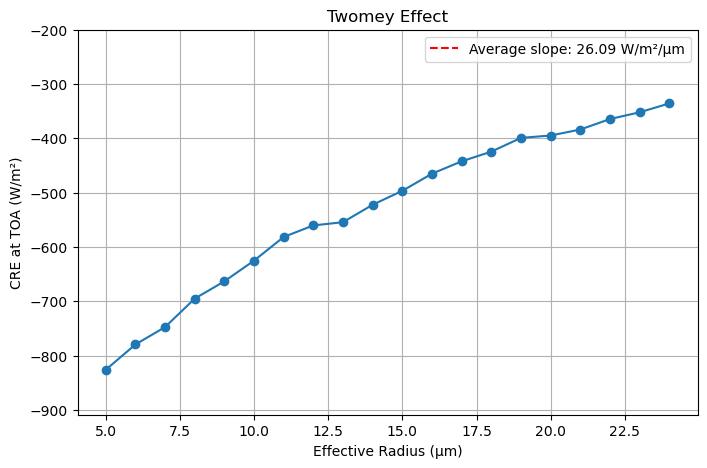

In [15]:

# sweep Reff from 5 to 25 microns
reff_values = np.arange(5, 25, 1)  # Reff from
layers_base = make_layers()  # base layers to modify for each Reff
CRE_values = []
for reff in reff_values:
    layers = make_layers(reff_um=reff)  # create layers with new Reff
    out = run_monte_carlo_cloud(layers, sza_deg=0.0, n_photons=10_000)
    albedo_cloudy = out['albedo']
    CRE = -S0*(albedo_cloudy - albedo_clear)
    CRE_values.append(CRE)
    print(f"Reff={reff:.1f} μm: CRE_TOA={CRE:.2f} W/m^2")
# plot CRE vs Reff
plt.figure(figsize=(8, 5))
plt.plot(reff_values, CRE_values, marker='o')
plt.title('Twomey Effect')
plt.xlabel('Effective Radius (μm)')
plt.ylabel('CRE at TOA (W/m²)')
plt.ylim(bottom=min(CRE_values)*1.1, top=-200)  # set y-axis limits to show negative CRE clearly
plt.grid()
# compute slope dCRE/dReff using np.gradient
CRE_array = np.array(CRE_values)
slope = np.gradient(CRE_array, reff_values)
print("Slope dCRE/dReff (W/m²/μm):")
for reff, s in zip(reff_values, slope):
    print(f"Reff={reff:.1f} μm: dCRE/dReff={s:.2f} W/m²/μm")
# average slope over the range
average_slope = np.mean(slope)
print(f"Average slope dCRE/dReff over {reff_values[0]}–{reff_values[-1]} μm: {average_slope:.2f} W/m²/μm")
# add av slope to the plot in a legend
plt.axhline(average_slope, color='red', linestyle='--', label=f"Average slope: {average_slope:.2f} W/m²/μm")
plt.legend()
plt.show()


### Q (c) — My own question

**Question:** If you hold a cloud's optical properties fixed and move it through the
atmosphere. Where does it produce the strongest SW cooling at TOA?

**Hypothesis:** Since in model the surface is perfectly absorbing, and the Taus are the same, I think that there will be no difference in surface transmittance, especially since the optical depth of the cloud is so big. If the surface could reflect radiation then the lower cloud could make the surface have more transmittion since the cloud could bounce more radiation back to the surface than a high cloud would. 

**Experiment:** keep cloud microphysics fixed (LWC = 0.30 g/m³, R_eff = 11 μm,
thickness = 250 m). Moved the cloud-top altitude from 0.5 km to
12 km in 11 steps.

Clear-sky albedo:  0.0251
Clear-sky T_total: 0.9146

z_top (km)    α_cloudy    CRE (W/m²)     T_dir    T_diff   T_total
----------------------------------------------------------------------
       0.5      0.4909        -634.0    0.0000    0.4069    0.4069
       2.1      0.4993        -645.5    0.0000    0.4117    0.4117
       3.8      0.5089        -658.5    0.0000    0.4123    0.4123
       5.4      0.5189        -672.2    0.0000    0.4073    0.4073
       7.1      0.5273        -683.6    0.0000    0.4053    0.4053
       8.7      0.5349        -693.8    0.0000    0.4038    0.4038
      10.4      0.5373        -697.1    0.0000    0.4037    0.4037
      12.0      0.5431        -705.0    0.0000    0.4023    0.4023


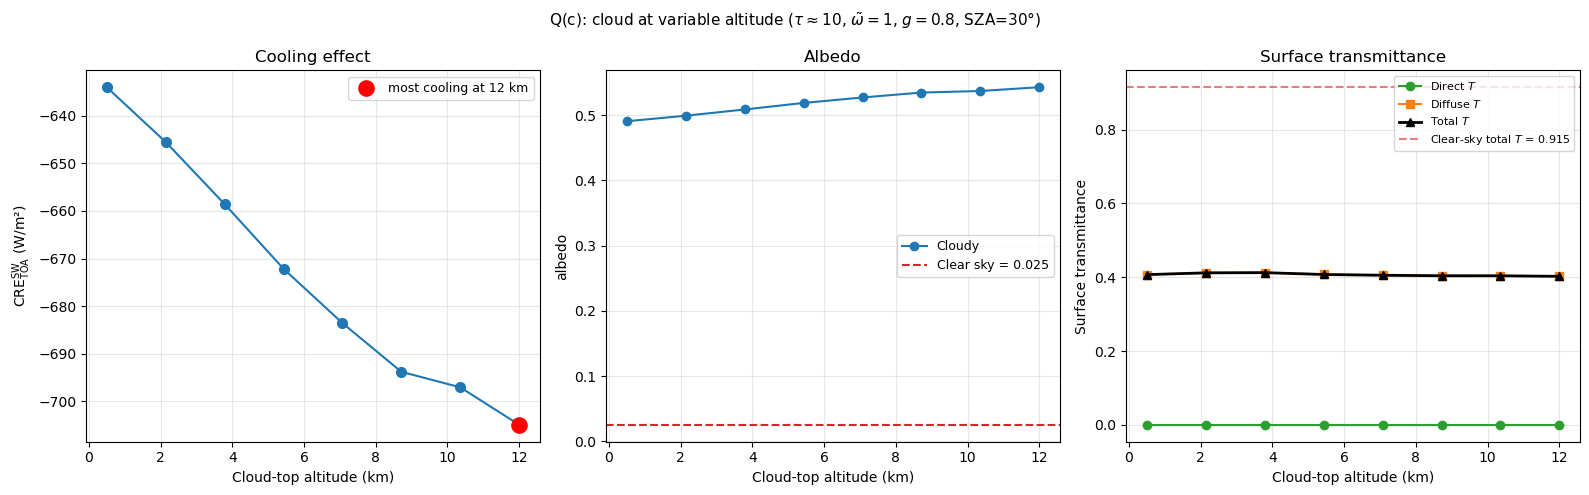


CRE range:        -705.0 to -634.0 W/m²  (variation: 71.0 W/m²)
T_total range:    0.402 to 0.412  (variation: 0.010)
Albedo range:     0.491 to 0.543  (variation: 0.052)


In [ ]:
# --- Q(c) experiment: cloud altitude vs CRE and surface transmittance ---


z_cloud_top_vals = np.linspace(500.0, 12_000.0, 8)   # meters

# --- Clear-sky reference ---
out_clear = run_monte_carlo_cloud(
    make_layers(cloud_thickness_m=0.0, lwc_g_m3=0.0),
    sza_deg=30, n_photons=15_000,
    rng=np.random.default_rng(seed=1),
)
alpha_clear   = out_clear['albedo']
T_dir_clear   = out_clear['T_direct']
T_diff_clear  = out_clear['T_diffuse']
T_total_clear = out_clear['T_total']
print(f"Clear-sky albedo:  {alpha_clear:.4f}")
print(f"Clear-sky T_total: {T_total_clear:.4f}\n")

# --- Sweep cloud altitude ---
alpha_cloudy_arr = np.zeros_like(z_cloud_top_vals)
T_dir_arr        = np.zeros_like(z_cloud_top_vals)
T_diff_arr       = np.zeros_like(z_cloud_top_vals)
T_total_arr      = np.zeros_like(z_cloud_top_vals)

print(f"{'z_top (km)':>10}  {'α_cloudy':>10}  {'CRE (W/m²)':>12}  "
      f"{'T_dir':>8}  {'T_diff':>8}  {'T_total':>8}")
print('-' * 70)
for i, z_top in enumerate(z_cloud_top_vals):
    layers = make_layers(z_cloud_top_m=z_top,
                         cloud_thickness_m=250.0,
                         reff_um=11.0,
                         lwc_g_m3=0.30)
    out = run_monte_carlo_cloud(layers, sza_deg=30, n_photons=15_000,
                                rng=np.random.default_rng(seed=1))
    alpha_cloudy_arr[i] = out['albedo']
    T_dir_arr[i]        = out['T_direct']
    T_diff_arr[i]       = out['T_diffuse']
    T_total_arr[i]      = out['T_total']
    cre = -S0 * (out['albedo'] - alpha_clear)
    print(f"{z_top/1000:>10.1f}  {out['albedo']:>10.4f}  {cre:>+12.1f}  "
          f"{out['T_direct']:>8.4f}  {out['T_diffuse']:>8.4f}  {out['T_total']:>8.4f}")

CRE_arr = -S0 * (alpha_cloudy_arr - alpha_clear)

# --- 3-panel plot: CRE, albedo, transmittance ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: CRE
ax = axes[0]
ax.plot(z_cloud_top_vals/1000, CRE_arr, 'o-', color='C0', ms=7)
idx_min = np.argmin(CRE_arr)
ax.scatter(z_cloud_top_vals[idx_min]/1000, CRE_arr[idx_min],
           color='red', zorder=5, s=120,
           label=f'most cooling at {z_cloud_top_vals[idx_min]/1000:g} km')
ax.set_xlabel('Cloud-top altitude (km)')
ax.set_ylabel(r'$\text{CRE}_{\rm TOA}^{\rm SW}$ (W/m²)')
ax.set_title('Cooling effect')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 2: Albedo
ax = axes[1]
ax.plot(z_cloud_top_vals/1000, alpha_cloudy_arr, 'o-', color='C0', label='Cloudy')
ax.axhline(alpha_clear, color='C3', ls='--', label=f'Clear sky = {alpha_clear:.3f}')
ax.set_xlabel('Cloud-top altitude (km)')
ax.set_ylabel('albedo')
ax.set_title('Albedo')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 3: Surface transmittance breakdown
ax = axes[2]
ax.plot(z_cloud_top_vals/1000, T_dir_arr,   'o-', color='C2', label='Direct $T$')
ax.plot(z_cloud_top_vals/1000, T_diff_arr,  's-', color='C1', label='Diffuse $T$')
ax.plot(z_cloud_top_vals/1000, T_total_arr, '^-', color='k',  lw=2, label='Total $T$')
ax.axhline(T_total_clear, color='C3', ls='--', alpha=0.6,
           label=f'Clear-sky total $T$ = {T_total_clear:.3f}')
ax.set_xlabel('Cloud-top altitude (km)')
ax.set_ylabel('Surface transmittance')
ax.set_title('Surface transmittance')
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3)

fig.suptitle(rf'Q(c): cloud at variable altitude ($\tau\approx 10$, $\tilde\omega=1$, $g=0.8$, SZA={30:g}°)',
             fontsize=11)
plt.tight_layout()
plt.savefig('figures/q7_3c_altitude_sweep.png', bbox_inches='tight')
plt.show()

# --- Summary stats ---
print(f"\nCRE range:        {CRE_arr.min():.1f} to {CRE_arr.max():.1f} W/m²  "
      f"(variation: {CRE_arr.max() - CRE_arr.min():.1f} W/m²)")
print(f"T_total range:    {T_total_arr.min():.3f} to {T_total_arr.max():.3f}  "
      f"(variation: {T_total_arr.max() - T_total_arr.min():.3f})")
## add albedo range
print(f"Albedo range:     {alpha_cloudy_arr.min():.3f} to {alpha_cloudy_arr.max():.3f}  "
      f"(variation: {alpha_cloudy_arr.max() - alpha_cloudy_arr.min():.3f})")


In [22]:
## add surface transmittance range
print(f"Surface T range:  {T_total_arr.min():.3f} to {T_total_arr.max():.3f}  "
      f"(variation: {T_total_arr.max() - T_total_arr.min():.3f})")  


Surface T range:  0.402 to 0.412  (variation: 0.010)


The surface transmittance does not change much. The CRE and albedo varies a more and has the more negative CRE when the cloud increases in hieght. I think this is because the photons reflect out of the atmosphere easier when the "lid" of the atmosphere is with in a better reach. The cloud is much more optically deep than the atmosphere so it reflects more. 

It is interesting that the albedo changes while than the surface transmittance stays similar but I guess this is because the surface can not reflect like a cloud. Which poses my new question, will surface transmition change with cloud height given a reflective surface?

To add surface reflectance, once the photon hits the surface it will either absorb or reflect, depending on the albedo — like in Part 1 of the homework where the photon either scatters or absorbs based on the single-scatter albedo. But unlike the isotropic scattering in Part 1, the reflection at the surface is Lambertian, and only in the upward direction since it can't scatter down into the ground. To get the direction, you can use  CDF of Lambert's cosine law; when you solve the CDF for cosine I get np.sqrt(ζ), which keeps cos_theta ≥ 0 so it is always up. Lambertian reflection is also a function of phi, where phi = 2π × ζ, because ϕ is uniform. (I did this part using claude)



In [19]:
def sample_lambertian_upward(rng):
    """Sample an upward-going direction from a Lambertian (cosine-weighted) PDF.
    Returns a unit vector with positive z-component (heading up, toward TOA).
    """
    cos_theta = np.sqrt(rng.uniform(0.0, 1.0))   
    sin_theta = np.sqrt(1.0 - cos_theta**2)
    phi = 2.0 * np.pi * rng.uniform(0.0, 1.0)
    return np.array([sin_theta * np.cos(phi),
                     sin_theta * np.sin(phi),
                     cos_theta])               #It returns one direction vector with three (x, y, z) 



def run_monte_carlo_cloud(layers, sza_deg, n_photons=15_000, rng=np.random.default_rng(seed=1),
                          n_traces=0, surface_albedo=0.0):
    """Three-layer (or N-layer) Monte Carlo for HW3 Part III.

    Parameters
    ----------
    layers : list of dicts, ordered from top of atmosphere to surface.
        Each dict has keys: 'tau_top', 'tau_bot', 'omega', 'g'.
        Convention: tau_top < tau_bot (deeper = larger tau).
    sza_deg, n_photons, rng, n_traces : same as Part II.
    surface_albedo : float in [0, 1]
        Fraction of photons hitting the surface that reflect back up with a
        Lambertian distribution. 0.0 = perfectly absorbing surface (default).

    Returns the same dict structure as run_monte_carlo_hg, plus 'surface_absorbed'.
    """
    mu0 = np.cos(np.deg2rad(sza_deg))
    tau_star = layers[-1]['tau_bot']

    if mu0 <= 0.0:
        return {'T_direct': 0.0, 'T_diffuse': 0.0, 'T_total': 0.0, 'albedo': 0.0,
                'absorptance': 1.0, 'surface_absorbed': 0.0, 'tau_star': tau_star,
                'sza_deg': sza_deg, 'mu0': mu0, 'layers': layers,
                'surface_albedo': surface_albedo, 'trajectories': []}

    sin_sza = np.sin(np.deg2rad(sza_deg))
    k_init  = np.array([sin_sza, 0.0, -mu0])

    def layer_at(tau_pos):
        for layer in layers:
            if layer['tau_top'] <= tau_pos <= layer['tau_bot']:
                return layer
        return layers[0] if tau_pos < 0 else layers[-1]

    n_direct, n_diffuse, n_reflected, n_absorbed, n_surf_absorbed = 0, 0, 0, 0, 0
    trajectories = []

    for i in range(n_photons):
        record_this = (i < n_traces)

        k         = k_init.copy()
        x         = 0.0
        tau_pos   = 0.0
        scattered = False
        traj      = [(x, tau_pos)] if record_this else None

        while True:
            ds        = sample_path_length(rng)
            dtau_vert = -ds * k[2]
            tau_pos_n = tau_pos + dtau_vert
            dx        =  ds * k[0]
            x_n       = x + dx

            # --- reaches surface ---
            if tau_pos_n >= tau_star:
                frac  = (tau_star - tau_pos) / dtau_vert
                x_hit = x + frac * dx
                if record_this:
                    traj.append((x_hit, tau_star))

                # NEW: surface reflection vs absorption
                if rng.uniform(0.0, 1.0) < surface_albedo:
                    # Reflected back up with a Lambertian direction — keep going
                    k         = sample_lambertian_upward(rng)
                    tau_pos   = tau_star
                    x         = x_hit
                    scattered = True   # bounced off the surface = part of the diffuse field
                    continue
                else:
                    # Absorbed by the surface — this photon's energy reaches the surface
                    if scattered:
                        n_diffuse += 1
                    else:
                        n_direct += 1
                    n_surf_absorbed += 1
                    break

            # --- escape: top of atmosphere ---
            if tau_pos_n <= 0.0:
                if record_this:
                    frac = (0.0 - tau_pos) / dtau_vert
                    traj.append((x + frac * dx, 0.0))
                n_reflected += 1
                break

            # --- interaction inside the atmosphere ---
            tau_pos = tau_pos_n
            x       = x_n
            if record_this:
                traj.append((x, tau_pos))

            layer = layer_at(tau_pos)
            omega = layer['omega']
            g     = layer['g']

            if rng.uniform(0.0, 1.0) >= omega:
                n_absorbed += 1     # absorbed in the atmosphere
                break

            cos_th, phi = sample_scatter_angles_hg(g, rng)
            k = rotate_to_model_frame(k, cos_th, phi)
            scattered = True

        if record_this:
            trajectories.append(np.array(traj))

    return {
        'T_direct':         n_direct        / n_photons,
        'T_diffuse':        n_diffuse       / n_photons,
        'T_total':         (n_direct + n_diffuse) / n_photons,
        'albedo':           n_reflected     / n_photons,
        'absorptance':      n_absorbed      / n_photons,   # atmospheric absorption only
        'surface_absorbed': n_surf_absorbed / n_photons,   # energy deposited at surface
        'n_direct':         n_direct,
        'n_diffuse':        n_diffuse,
        'n_reflected':      n_reflected,
        'n_absorbed':       n_absorbed,
        'n_surf_absorbed':  n_surf_absorbed,
        'trajectories':     trajectories,
        'tau_star':         tau_star,
        'sza_deg':          sza_deg,
        'mu0':              mu0,
        'surface_albedo':   surface_albedo,
        'layers':           layers,
    }

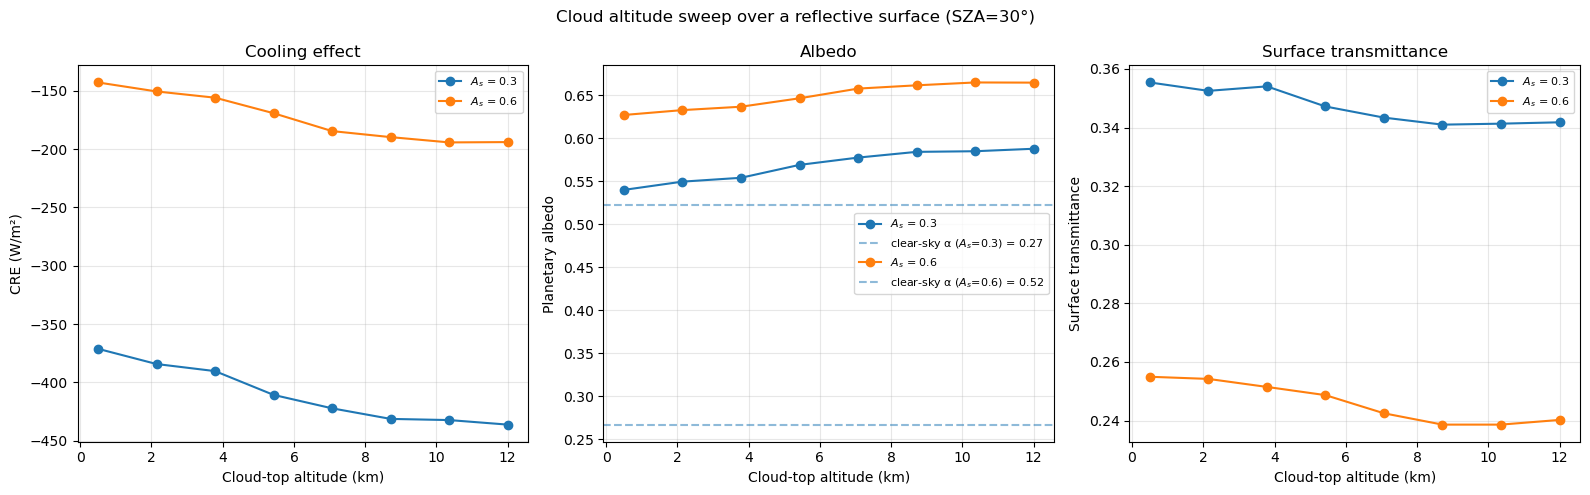

Surface T range (A_s=0.3):  0.239 to 0.255  (variation: 0.016)
Albedo range (A_s=0.3):     0.627 to 0.665  (variation: 0.038)


In [ ]:
z_vals = np.linspace(500, 12000, 8)
z_km   = z_vals / 1000

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
#store results for both surface albedo cases in lists to plot them together

for A_s in [0.3, 0.6]:
    # Clear-sky reference at this surface albedo
    out_clear = run_monte_carlo_cloud(make_layers(lwc_g_m3=0.0), sza_deg=30,
                                      n_photons=15_000, surface_albedo=A_s,
                                      rng=np.random.default_rng(seed=1))
    alpha_clear = out_clear['albedo']

    CRE_by_alt   = []
    alpha_by_alt = []
    Ttot_by_alt  = []
    for z_top in z_vals:
        out = run_monte_carlo_cloud(make_layers(z_cloud_top_m=z_top),
                                    sza_deg=30, n_photons=15_000,
                                    surface_albedo=A_s,
                                    rng=np.random.default_rng(seed=1))
        CRE_by_alt.append(-1361 * (out['albedo'] - alpha_clear))
        alpha_by_alt.append(out['albedo'])
        Ttot_by_alt.append(out['T_total'])

    axes[0].plot(z_km, CRE_by_alt,   'o-', label=f'$A_s$ = {A_s}')
    axes[1].plot(z_km, alpha_by_alt, 'o-', label=f'$A_s$ = {A_s}')
    axes[2].plot(z_km, Ttot_by_alt,  'o-', label=f'$A_s$ = {A_s}')
    # Mark the clear-sky albedo for this A_s as a horizontal reference
    axes[1].axhline(alpha_clear, ls='--', alpha=0.5,
                    label=f'clear-sky α ($A_s$={A_s}) = {alpha_clear:.2f}')

axes[0].set_xlabel('Cloud-top altitude (km)'); axes[0].set_ylabel('CRE (W/m²)')
axes[0].set_title('Cooling effect'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Cloud-top altitude (km)'); axes[1].set_ylabel('Planetary albedo')
axes[1].set_title('Albedo'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].set_xlabel('Cloud-top altitude (km)'); axes[2].set_ylabel('Surface transmittance')
axes[2].set_title('Surface transmittance'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

fig.suptitle('Cloud altitude sweep over a reflective surface (SZA=30°)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/q7_3c_altitude_surface_albedo.png', bbox_inches='tight')
plt.show()
## add surface transmittance range
print(f"Surface T range (A_s=0.6):  {min(Ttot_by_alt):.3f} to {max(Ttot_by_alt):.3f}  "
      f"(variation: {max(Ttot_by_alt) - min(Ttot_by_alt):.3f})")
#add albedo range
print(f"Albedo range (A_s=0.6):     {min(alpha_by_alt):.3f} to {max(alpha_by_alt):.3f}  "
      f"(variation: {max(alpha_by_alt) - min(alpha_by_alt):.3f})")

When I added surface reflectance I did see a slighly larger change in the surface transmittance 0.016 versus 0.010, has you increases the cloud top altitude this is still pretty small. Interestingly the albedo showed less variation has you increase the cloud altitude, with out surface reflection it changed by 0.052 and whith surface reflection it changed by 0.038. 

---
## AI Usage Statement

**Tool used:** Claude (Anthropic)

**How it was used:**
I used claude to help me with my functions particularly adding the layers into my model, I thought it would be simpler to have a layer function defining where the different optical depths started and stopped but I needed up adding it to my full MC model. I also heavily relied on claude to add surface albedo to the model. I did not know the PDF for lambertian scattering or that I needed to also use phi, so I had to ask it clarifying questions to make sure I was understanding what was going on. I gave claude the fuction and the HW and asked to add surface reflectance, based on a input value of albedo, and to have the reflectance reflect uniformly. 

To check that claude did this correctly I added a no cloud clear atmopshere and looked at the traces to make sure they reflectupwards. I also read thw wiki page etc. 

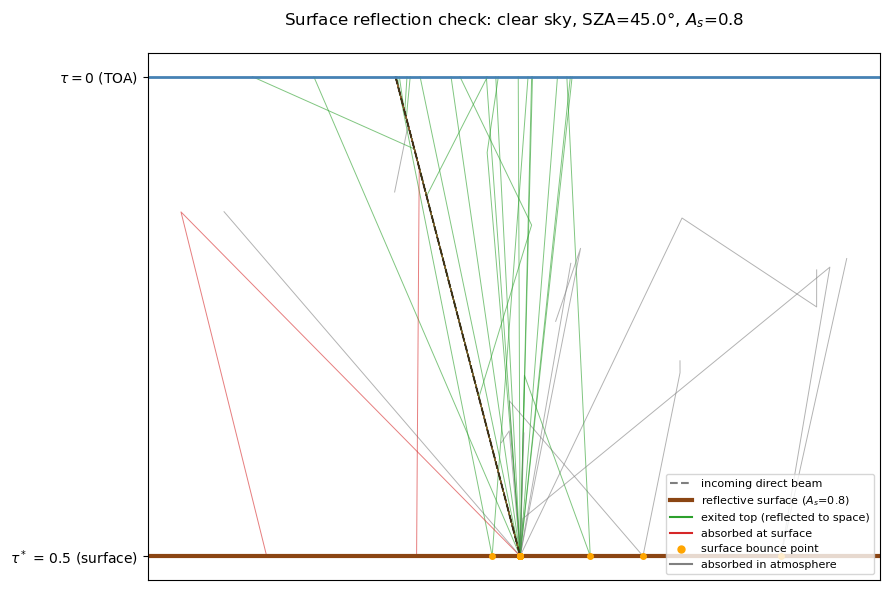

Surface albedo input: 0.8
Albedo (exited top):       0.350
Absorbed at surface:       0.150


In [27]:
# --- Verification: surface reflection sends photons back up ---


tau_clear  = 0.5         
sza_deg    = 45.0         
A_s        = 0.8         
n_trace    = 60

# Single clear layer (no cloud): isotropic scattering, omega=1
layers_check = [{
    'name':    'clear sky',
    'tau_top': 0.0,
    'tau_bot': tau_clear,
    'omega':   0.5,
    'g':       0.0,
}]

out = run_monte_carlo_cloud(layers_check, sza_deg=sza_deg,
                            n_photons=n_trace, n_traces=n_trace,
                            surface_albedo=A_s,
                            rng=np.random.default_rng(seed=7))

# Direct-beam reference
sin_sza = np.sin(np.deg2rad(sza_deg))
mu0     = np.cos(np.deg2rad(sza_deg))
x_end   = (tau_clear / mu0) * sin_sza

fig, ax = plt.subplots(figsize=(9, 6))

for traj in out['trajectories']:
    end_tau = traj[-1, 1]
    # Color by where the photon ended up
    if   np.isclose(end_tau, 0.0):        color = 'C2'   # exited top
    elif np.isclose(end_tau, tau_clear):  color = 'C3'   # absorbed at surface
    else:                                 color = 'gray' # absorbed in atmosphere 
    ax.plot(traj[:, 0], traj[:, 1], '-', color=color, lw=0.7, alpha=0.6)
    # Mark surface-bounce points (where trajectory touches tau = tau_clear mid-path)
    for j in range(1, len(traj) - 1):
        if np.isclose(traj[j, 1], tau_clear):
            ax.plot(traj[j, 0], traj[j, 1], 'o', color='orange', ms=4, zorder=5)

# Direct beam + boundaries
ax.plot([0, x_end], [0, tau_clear], 'k--', lw=1.5, alpha=0.5, label='incoming direct beam')
ax.axhline(0,         color='steelblue', lw=2)
ax.axhline(tau_clear, color='saddlebrown', lw=3, label=f'reflective surface ($A_s$={A_s})')

ax.invert_yaxis()      # tau increases downward
ax.set_yticks([0, tau_clear])
ax.set_yticklabels([r'$\tau = 0$ (TOA)', rf'$\tau^*$ = {tau_clear} (surface)'])
ax.set_xticks([])

# Legend (dummy entries for the fate colors)
ax.plot([], [], '-', color='C2', lw=1.5, label='exited top (reflected to space)')
ax.plot([], [], '-', color='C3', lw=1.5, label='absorbed at surface')
ax.plot([], [], 'o', color='orange', ms=5, label='surface bounce point')
ax.plot([], [], '-', color='gray', lw=1.5, label='absorbed in atmosphere')
ax.legend(loc='lower right', fontsize=8)

ax.set_title(f'Surface reflection check: clear sky, SZA={sza_deg}°, $A_s$={A_s}\n')
plt.tight_layout()
plt.savefig('figures/surface_reflection_check.png', bbox_inches='tight')
plt.show()

# --- Numerical checks ---
print(f"Surface albedo input: {A_s}")
print(f"Albedo (exited top):       {out['albedo']:.3f}")
print(f"Absorbed at surface:       {out['surface_absorbed']:.3f}")